# Compare single-cell BO vs FOV-aggregate BO (gpax both sides)

Feeds the **same raw data** into two BO formulations:

- **single-cell**: `OscillationBOSingleCell` (gpax `viSparseGP`) - one row per cell
- **FOV-aggregate**: `OscillationBO` (gpax ExactGP + NUTS MCMC) - one row per FOV

Both use the objective `mean_osc_probability`. For the FOV model we also
compute the FOV-level **median** of per-cell mean oscillation probability
as a secondary objective and fit a third GP on it -- the median is
more robust to a few strongly oscillating cells that can dominate an
FOV's mean.

The comparison answers:

1. Which formulation has a better-calibrated GP (R2, coverage, NLPD)?
2. Do the backends agree on which variables matter (ARD lengthscales)?
3. Do they pick the same next `(stim_exposure, ramp)` point?
4. Does FOV-median beat FOV-mean as a BO target?


In [13]:
import os, importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# gpax/numpyro compat shim
import numpyro.contrib.module as _ncm


def _haiku_unavailable(*_a, **_k):
    raise NotImplementedError("haiku removed")


if not hasattr(_ncm, "random_haiku_module"):
    _ncm.random_haiku_module = _haiku_unavailable
if not hasattr(_ncm, "haiku_module"):
    _ncm.haiku_module = _haiku_unavailable

# ---- User config ----
RUN_PATH = r"E:\Alex\2026-04-10_bo_erk_oscillation_v4_test"
EXP_DATA_PATH = os.path.join(RUN_PATH, "exp_data.parquet")

N_FRAMES_BASELINE = 10
N_FRAMES_STIM = 60
N_FRAMES_RECOVERY = 20
N_FRAMES = N_FRAMES_BASELINE + N_FRAMES_STIM + N_FRAMES_RECOVERY
FIRST_FRAME_STIM = N_FRAMES_BASELINE
LAST_FRAME_STIM = FIRST_FRAME_STIM + N_FRAMES_STIM

CLASSIFIER_PATH = r"./oscillation_model_60min.joblib"
CLASSIFIER_SCRIPT = r"./apply_oscillation_classifier_v2.py"

N_CONDITIONS_PER_ITER = 2
N_INITIAL_PHASES = 2

In [14]:
import joblib

model_data = joblib.load(CLASSIFIER_PATH)
osc_clf = model_data["clf"]
osc_scaler = model_data["scaler"]
osc_feature_cols = model_data["feature_cols"]
osc_cfg = model_data["config"]
osc_cfg["window_size"] = model_data["window_size"]
osc_cfg["window_step"] = model_data["window_step"]

_spec = importlib.util.spec_from_file_location("osc_clf_mod", CLASSIFIER_SCRIPT)
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
predict_trace = _mod.predict_trace

df_exp = pd.read_parquet(EXP_DATA_PATH)
cond_map_df = (
    df_exp.groupby(["phase_id", "fov"])
    .agg(stim_exposure=("stim_exposure", "first"), ramp=("ramp", "first"))
    .reset_index()
)
phases = sorted(df_exp["phase_id"].unique())
print(
    f"Loaded {len(df_exp)} rows, {len(phases)} phases, {df_exp['fov'].nunique()} FOVs"
)

Loaded 688761 rows, 9 phases, 162 FOVs


## Instantiate both BO agents

Both use gpax as the backend library but with different GP flavors:
- `OscillationBOSingleCell` -> `viSparseGP` (SVI, variational)
- `OscillationBO` -> `ExactGP` with NUTS MCMC (original gpax backend)

You can crank `num_warmup` / `num_samples` up or down to trade off MCMC
quality vs runtime for the FOV side.


In [15]:
from faro.agents.bo_optimization import BO_Parameter, BO_Objective, BO_Covariate
from faro.agents.bo_oscillation import OscillationBO
from faro.agents.bo_oscillation_single_cell import OscillationBOSingleCell

bo_params = [
    BO_Parameter(name="stim_exposure", bounds=(50.0, 500.0), spacing=25.0),
    BO_Parameter(name="ramp", bounds=(0.0, 20.0), spacing=5.0),
]
bo_objective = BO_Objective(name="mean_osc_probability", goal="maximize")

# Per-cell covariates
bo_covariates_cell = [
    BO_Covariate(name="baseline_cnr"),
    BO_Covariate(name="optortk_expression", log_scale=True),
    BO_Covariate(name="mean_dist_k_nearest"),
]

# Per-FOV covariates
bo_covariates_fov = [
    BO_Covariate(name="baseline_cnr"),
    BO_Covariate(name="optortk_expression", log_scale=True),
    BO_Covariate(name="n_cells"),
]

shared_kwargs = dict(
    n_frames=N_FRAMES,
    first_frame_stim=FIRST_FRAME_STIM,
    last_frame_stim=LAST_FRAME_STIM,
    time_between_timesteps=60,
    imaging_channels=(),
    stim_channel=None,
    optocheck_channel=None,
    osc_clf=osc_clf,
    osc_scaler=osc_scaler,
    osc_feature_cols=osc_feature_cols,
    osc_cfg=osc_cfg,
    osc_predict_fn=predict_trace,
    min_osc_probability=0.0,
    min_consecutive_windows=0,
    min_fft_amplitude=0.0,
    n_baseline_frames=N_FRAMES_BASELINE,
    parameters_to_optimize=bo_params,
    objective_metric=bo_objective,
    n_iterations=len(phases),
    n_conditions_per_iter=N_CONDITIONS_PER_ITER,
    n_initial_phases=N_INITIAL_PHASES,
    acquisition_function="ei",
    n_cov_samples=20,
    ei_xi=0.2,
    ei_xi_final=0.01,
    ei_xi_decay_fraction=0.7,
    plot_live=False,
    save_checkpoints=False,
    verbose=False,
)

# single-cell (viSparseGP)
agent_cell = OscillationBOSingleCell(
    storage_path=os.path.join(RUN_PATH, "replay_cell_vs_fov_cell"),
    gp_backend="vi_sparse",
    inducing_points_ratio=0.1,
    num_svi_steps=1500,
    svi_step_size=5e-3,
    gp_batch_size=2000,
    density_k_neighbours=5,
    bo_covariates=bo_covariates_cell,
    **shared_kwargs,
)
os.makedirs(agent_cell.storage_path, exist_ok=True)
agent_cell._ensure_results_df()

# FOV (ExactGP MCMC)
agent_fov = OscillationBO(
    storage_path=os.path.join(RUN_PATH, "replay_cell_vs_fov_fov"),
    bo_covariates=bo_covariates_fov,
    **shared_kwargs,
)
os.makedirs(agent_fov.storage_path, exist_ok=True)
agent_fov._ensure_results_df()

print(
    f"single-cell agent: {type(agent_cell).__name__}  (backend={agent_cell.gp_backend})"
)
print(f"FOV agent:         {type(agent_fov).__name__}   (backend=ExactGP+MCMC)")

single-cell agent: OscillationBOSingleCell  (backend=vi_sparse)
FOV agent:         OscillationBO   (backend=ExactGP+MCMC)


## Preprocess each phase with both agents

Each agent's own `_preprocess_results` runs on the same per-phase
`fov_tracks` dict. We additionally compute a per-FOV **median** of the
per-cell `mean_osc_probability` -- a robust alternative to the FOV mean.


In [16]:
all_cell_rows, all_fov_rows = [], []

for phase_id in phases:
    df_phase_raw = df_exp[df_exp["phase_id"] == phase_id]
    fov_tracks = {
        int(fov): df_phase_raw[df_phase_raw["fov"] == fov].copy()
        for fov in df_phase_raw["fov"].unique()
    }
    cm = cond_map_df[cond_map_df["phase_id"] == phase_id]
    cond_map = {
        int(row["fov"]): dict(
            stim_exposure=float(row["stim_exposure"]), ramp=float(row["ramp"])
        )
        for _, row in cm.iterrows()
    }

    agent_cell._current_condition_map = cond_map
    agent_cell._current_phase_id = int(phase_id)
    df_cell = agent_cell._preprocess_results(fov_tracks)
    if not df_cell.empty:
        all_cell_rows.append(df_cell)

    agent_fov._current_condition_map = cond_map
    agent_fov._current_phase_id = int(phase_id)
    df_fov = agent_fov._preprocess_results(fov_tracks)
    if not df_fov.empty:
        all_fov_rows.append(df_fov)

df_cells = pd.concat(all_cell_rows, ignore_index=True)
df_fovs = pd.concat(all_fov_rows, ignore_index=True)
# Drop FOVs/cells with non-positive optortk_expression (log-scale requires > 0)
n_c0, n_f0 = len(df_cells), len(df_fovs)
df_cells = df_cells[df_cells["optortk_expression"] > 0].reset_index(drop=True)
df_fovs = df_fovs[df_fovs["optortk_expression"] > 0].reset_index(drop=True)
print(
    f"Dropped {n_c0 - len(df_cells)} cells and {n_f0 - len(df_fovs)} FOVs with optortk_expression <= 0"
)

# FOV-level median of per-cell mean_osc_probability (from cell-level df)
fov_median = (
    df_cells.groupby(["phase_id", "fov"])["mean_osc_probability"]
    .median()
    .rename("median_osc_probability")
    .reset_index()
)
df_fovs = df_fovs.merge(fov_median, on=["phase_id", "fov"], how="left")
df_fovs["median_osc_probability"] = df_fovs["median_osc_probability"].fillna(0.0)

agent_cell.df_results = df_cells.copy()
agent_fov.df_results = df_fovs.copy()

print(
    f"\nsingle-cell rows: {len(df_cells)}  (across {df_cells['phase_id'].nunique()} phases)"
)
print(
    f"FOV rows:         {len(df_fovs)}   (across {df_fovs['phase_id'].nunique()} phases)"
)
print(f"\nCorrelation FOV-mean vs FOV-median (should be <1 if they disagree):")
print(
    f"  Pearson: {df_fovs[['mean_osc_probability','median_osc_probability']].corr().iloc[0,1]:.3f}"
)
print(f"  target std -- cells: {df_cells['mean_osc_probability'].std():.4f}")
print(f"  target std -- fovs (mean):   {df_fovs['mean_osc_probability'].std():.4f}")
print(f"  target std -- fovs (median): {df_fovs['median_osc_probability'].std():.4f}")

  Phase 0: 655 cells (from 18 FOVs), mean mean_osc_probability=0.1092, max=0.9960
  Phase 0: 18 FOVs, mean frac_oscillating=1.0000, max=1.0000
  Phase 1: 285 cells (from 17 FOVs), mean mean_osc_probability=0.1577, max=0.9805
  Phase 1: 12 FOVs, mean frac_oscillating=1.0000, max=1.0000
  Phase 2: 677 cells (from 18 FOVs), mean mean_osc_probability=0.1794, max=0.9969
  Phase 2: 18 FOVs, mean frac_oscillating=0.9986, max=1.0000
  Phase 3: 435 cells (from 18 FOVs), mean mean_osc_probability=0.2145, max=0.9926
  Phase 3: 18 FOVs, mean frac_oscillating=1.0000, max=1.0000
  Phase 4: 409 cells (from 18 FOVs), mean mean_osc_probability=0.2393, max=0.9976
  Phase 4: 17 FOVs, mean frac_oscillating=1.0000, max=1.0000
  Phase 5: 551 cells (from 18 FOVs), mean mean_osc_probability=0.1955, max=0.9980
  Phase 5: 18 FOVs, mean frac_oscillating=1.0000, max=1.0000
  Phase 6: 444 cells (from 18 FOVs), mean mean_osc_probability=0.2820, max=0.9901
  Phase 6: 18 FOVs, mean frac_oscillating=1.0000, max=1.0000

## Fit all three GPs on the full cumulative dataset

1. single-cell: viSparseGP on `mean_osc_probability`
2. FOV-mean: ExactGP MCMC on `mean_osc_probability`
3. FOV-median: ExactGP MCMC on `median_osc_probability` (separate agent, shares preprocessing)


In [17]:
# --- Fit single-cell viSparseGP
agent_cell.iteration = len(phases) - 1
agent_cell._last_plot_context = None
print("=== single-cell viSparseGP ===")
params_cell = agent_cell._determine_next_parameters(
    agent_cell.df_results, verbose=False
)

# --- Fit FOV ExactGP on mean
agent_fov.iteration = len(phases) - 1
agent_fov._last_plot_context = None
print("\n=== FOV ExactGP (mean target) ===")
params_fov_mean = agent_fov._determine_next_parameters(
    agent_fov.df_results, verbose=False
)

# --- Fit FOV ExactGP on median (reuses the same class with different objective)
agent_fov_med = OscillationBO(
    storage_path=os.path.join(RUN_PATH, "replay_cell_vs_fov_fov_median"),
    bo_covariates=bo_covariates_fov,
    **{
        **shared_kwargs,
        "objective_metric": BO_Objective(
            name="median_osc_probability", goal="maximize"
        ),
    },
)
os.makedirs(agent_fov_med.storage_path, exist_ok=True)
agent_fov_med.df_results = df_fovs.copy()
agent_fov_med.iteration = len(phases) - 1
agent_fov_med._last_plot_context = None
print("\n=== FOV ExactGP (median target) ===")
params_fov_med = agent_fov_med._determine_next_parameters(
    agent_fov_med.df_results, verbose=False
)

print(f"\nNext pick -- single-cell:    {params_cell}")
print(f"Next pick -- FOV (mean):     {params_fov_mean}")
print(f"Next pick -- FOV (median):   {params_fov_med}")


# --- Cache the full-data fits so the landscape cell can skip refitting ---
def _snapshot(agent):
    return dict(
        model=agent.model,
        _x_scaler=agent._x_scaler,
        _y_scaler=agent._y_scaler,
        _rng_key_predict=getattr(agent, "_rng_key_predict", None),
        df_results=agent.df_results.copy(),
        _last_plot_context=getattr(agent, "_last_plot_context", None),
    )


_full_fit = {
    "cell": _snapshot(agent_cell),
    "fov": _snapshot(agent_fov),
    "fov_med": _snapshot(agent_fov_med),
}

=== single-cell viSparseGP ===
  Fitting vi_sparse on 4387 observations (5-D)...
  ARD lengthscales (small = highly relevant):
    stim_exposure                 lengthscale= 0.139
    ramp                          lengthscale= 0.562
    baseline_cnr                  lengthscale= 4.381
    optortk_expression            lengthscale= 0.989
    mean_dist_k_nearest           lengthscale= 3.217
    k_scale=0.258   noise=0.801
  Predicting 1900 points (95 grid x 20 cov samples)...

=== FOV ExactGP (mean target) ===


sample: 100%|██████████| 1200/1200 [00:13<00:00, 91.18it/s, 15 steps of size 2.98e-01. acc. prob=0.89] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      2.33      2.42      1.65      0.08      5.24    807.72      1.00
k_length[1]      1.68      1.61      1.23      0.04      3.38    585.54      1.00
k_length[2]      1.14      1.37      0.68      0.05      2.47    328.32      1.00
k_length[3]      0.49      0.70      0.21      0.06      1.22    311.99      1.00
k_length[4]      1.63      1.95      0.99      0.14      3.37    191.70      1.00
    k_scale      0.48      0.24      0.45      0.11      0.86    195.30      1.00
      noise      0.60      0.23      0.62      0.21      0.94    148.01      1.00

Computing robust acquisition over 1900 scenarios (95 grid points x 20 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.186279
  Robust acq stats: min=0.040273, max=0.194909

=== FOV ExactGP (median target) ===


sample: 100%|██████████| 1200/1200 [00:13<00:00, 89.14it/s, 7 steps of size 3.08e-01. acc. prob=0.92]  



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.32      1.87      0.70      0.02      3.24    606.58      1.00
k_length[1]      1.49      1.63      0.95      0.05      3.22    378.79      1.00
k_length[2]      0.90      1.59      0.48      0.02      1.96    396.55      1.00
k_length[3]      0.88      1.15      0.48      0.03      2.13    303.53      1.00
k_length[4]      2.10      2.19      1.37      0.11      4.52    423.92      1.00
    k_scale      0.41      0.21      0.38      0.05      0.70    214.29      1.00
      noise      0.66      0.22      0.68      0.31      1.01    203.58      1.00

Computing robust acquisition over 1900 scenarios (95 grid points x 20 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.348789
  Robust acq stats: min=0.037365, max=0.239677

Next pick -- single-cell:    {'stim_exposure': np.float64(175.0), 'ramp': np.float64(20.0)}
Next pick -- FOV (mean):     {'stim_exposure': n

## ARD lengthscales side-by-side

Small = high relevance (within-backend comparison only -- each agent
scales its inputs independently).


--- single-cell viSparseGP (mean) ---
  stim_exposure                 ls=  0.139  rel=1.00
  ramp                          ls=  0.562  rel=0.25
  optortk_expression            ls=  0.989  rel=0.14
  mean_dist_k_nearest           ls=  3.217  rel=0.04
  baseline_cnr                  ls=  4.381  rel=0.03

--- FOV ExactGP (mean) ---
  optortk_expression            ls=  0.488  rel=1.00
  baseline_cnr                  ls=  1.136  rel=0.43
  n_cells                       ls=  1.627  rel=0.30
  ramp                          ls=  1.684  rel=0.29
  stim_exposure                 ls=  2.330  rel=0.21

--- FOV ExactGP (median) ---
  optortk_expression            ls=  0.877  rel=1.00
  baseline_cnr                  ls=  0.897  rel=0.98
  stim_exposure                 ls=  1.319  rel=0.66
  ramp                          ls=  1.488  rel=0.59
  n_cells                       ls=  2.096  rel=0.42


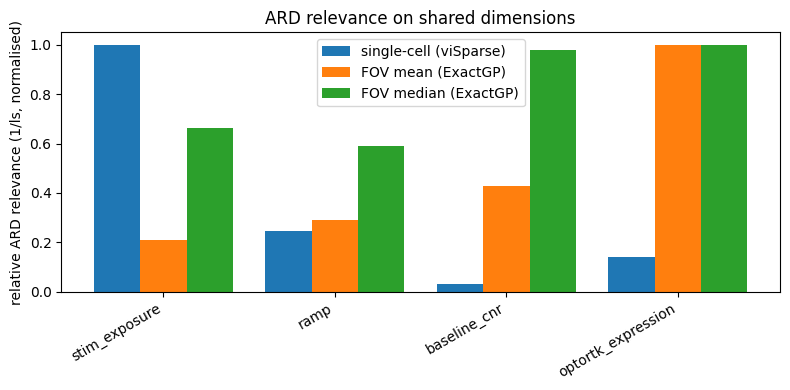

In [18]:
def _ls_from(agent):
    s = np.asarray(agent.model.get_samples()["k_length"])
    if s.ndim > 1:
        s = s.mean(axis=0)
    return s.squeeze()


dim_cell = [p.name for p in agent_cell.parameters_to_optimize] + [
    c.name for c in agent_cell.bo_covariates
]
dim_fov = [p.name for p in agent_fov.parameters_to_optimize] + [
    c.name for c in agent_fov.bo_covariates
]

ls_cell = _ls_from(agent_cell)
ls_fov = _ls_from(agent_fov)
ls_fov_med = _ls_from(agent_fov_med)


def _show(names, ls, label):
    rel = 1.0 / ls
    rel /= rel.max()
    print(f"--- {label} ---")
    for n, l, r in sorted(zip(names, ls, rel), key=lambda t: t[1]):
        print(f"  {n:28s}  ls={float(l):7.3f}  rel={float(r):.2f}")
    return rel


rel_cell = _show(dim_cell, ls_cell, "single-cell viSparseGP (mean)")
print()
rel_fov = _show(dim_fov, ls_fov, "FOV ExactGP (mean)")
print()
rel_fov_m = _show(dim_fov, ls_fov_med, "FOV ExactGP (median)")

# Bar plot on shared dims
common = [n for n in dim_cell if n in dim_fov]
c_idx = [dim_cell.index(n) for n in common]
f_idx = [dim_fov.index(n) for n in common]
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(common))
w = 0.27
ax.bar(x - w, rel_cell[c_idx], w, label="single-cell (viSparse)")
ax.bar(x, rel_fov[f_idx], w, label="FOV mean (ExactGP)")
ax.bar(x + w, rel_fov_m[f_idx], w, label="FOV median (ExactGP)")
ax.set_xticks(x)
ax.set_xticklabels(common, rotation=30, ha="right")
ax.set_ylabel("relative ARD relevance (1/ls, normalised)")
ax.set_title("ARD relevance on shared dimensions")
ax.legend()
plt.tight_layout()
plt.show()

## Training-set GP diagnostics

Shared helper handles both viSparseGP (returns `mean, var` directly)
and ExactGP MCMC (returns `mean, samples`; variance is computed
empirically from the posterior).


In [19]:
import gpax


def _predict_gpax(agent, X_raw, is_exact_mcmc, n_samples=64, need_var=True):
    X_scaled = np.asarray(agent._x_scaler.transform(X_raw))
    rng = getattr(agent, "_rng_key_predict", None)
    if rng is None:
        _, rng = gpax.utils.get_keys()
    chunk = 2000
    means, vars_ = [], []
    for i in range(0, X_scaled.shape[0], chunk):
        Xb = X_scaled[i : i + chunk]
        if is_exact_mcmc:
            mean_b, y_samp = agent.model.predict(rng, Xb, n=n_samples, noiseless=True)
            means.append(np.asarray(mean_b).flatten())
            if need_var:
                y_samp = np.asarray(y_samp)
                y_flat = y_samp.reshape(-1, y_samp.shape[-1])
                vars_.append(y_flat.var(axis=0))
            else:
                vars_.append(np.zeros(np.asarray(mean_b).shape[-1]))
        else:
            mean_b, cov_b = agent.model.predict(rng, Xb, noiseless=True)
            mean_b = np.asarray(mean_b).flatten()
            cov_b = np.asarray(cov_b)
            if cov_b.ndim == 2 and cov_b.shape[0] == cov_b.shape[1] == mean_b.shape[0]:
                var_b = np.diag(cov_b)
            else:
                var_b = cov_b.flatten()
            means.append(mean_b)
            vars_.append(var_b)
    mean_s = np.concatenate(means)
    var_s = np.concatenate(vars_)
    mean = agent._y_scaler.inverse_transform(mean_s.reshape(-1, 1)).flatten()
    std = np.sqrt(np.maximum(var_s, 1e-12)) * float(
        np.abs(np.asarray(agent._y_scaler.std_)[0])
    )
    return mean, std


def _metrics(agent, df, is_exact_mcmc, y_col=None):
    cols = [p.name for p in agent.parameters_to_optimize] + [
        c.name for c in agent.bo_covariates
    ]
    y_name = y_col or agent.objective_metric.name
    y = df[y_name].to_numpy(dtype=float)
    X = df[cols].to_numpy(dtype=float)
    m, s = _predict_gpax(agent, X, is_exact_mcmc)
    resid = y - m
    ss_res = float(np.sum(resid**2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    r2 = 1 - ss_res / max(ss_tot, 1e-12)
    rmse = float(np.sqrt(np.mean(resid**2)))
    nlpd = float(np.mean(0.5 * np.log(2 * np.pi * s**2) + 0.5 * (resid**2) / (s**2)))
    cov = float(np.mean((y >= m - 1.96 * s) & (y <= m + 1.96 * s)))
    z_std = float(np.std(resid / np.maximum(s, 1e-12)))
    return dict(
        r2=r2, rmse=rmse, nlpd=nlpd, coverage=cov, z_std=z_std, mean=m, std=s, y=y
    )


train_cell = _metrics(agent_cell, df_cells, is_exact_mcmc=False)
train_fov = _metrics(agent_fov, df_fovs, is_exact_mcmc=True)
train_fov_med = _metrics(agent_fov_med, df_fovs, is_exact_mcmc=True)

summary = pd.DataFrame(
    {
        "single-cell (viSparse)": [
            train_cell[k] for k in ("r2", "rmse", "nlpd", "coverage", "z_std")
        ],
        "FOV mean (ExactGP)": [
            train_fov[k] for k in ("r2", "rmse", "nlpd", "coverage", "z_std")
        ],
        "FOV median (ExactGP)": [
            train_fov_med[k] for k in ("r2", "rmse", "nlpd", "coverage", "z_std")
        ],
    },
    index=["R2", "RMSE", "NLPD (lower=better)", "95% coverage", "z-score std"],
)
print(summary.round(4))
print(f"\nn: cells={len(df_cells)}, fovs={len(df_fovs)}")

                     single-cell (viSparse)  FOV mean (ExactGP)  \
R2                                   0.2322              0.6431   
RMSE                                 0.2329              0.1020   
NLPD (lower=better)                 15.6972             -1.0028   
95% coverage                         0.3615              0.9542   
z-score std                          5.9826              1.0967   

                     FOV median (ExactGP)  
R2                                 0.5753  
RMSE                               0.0612  
NLPD (lower=better)               -1.5368  
95% coverage                       0.9150  
z-score std                        1.1525  

n: cells=4387, fovs=153


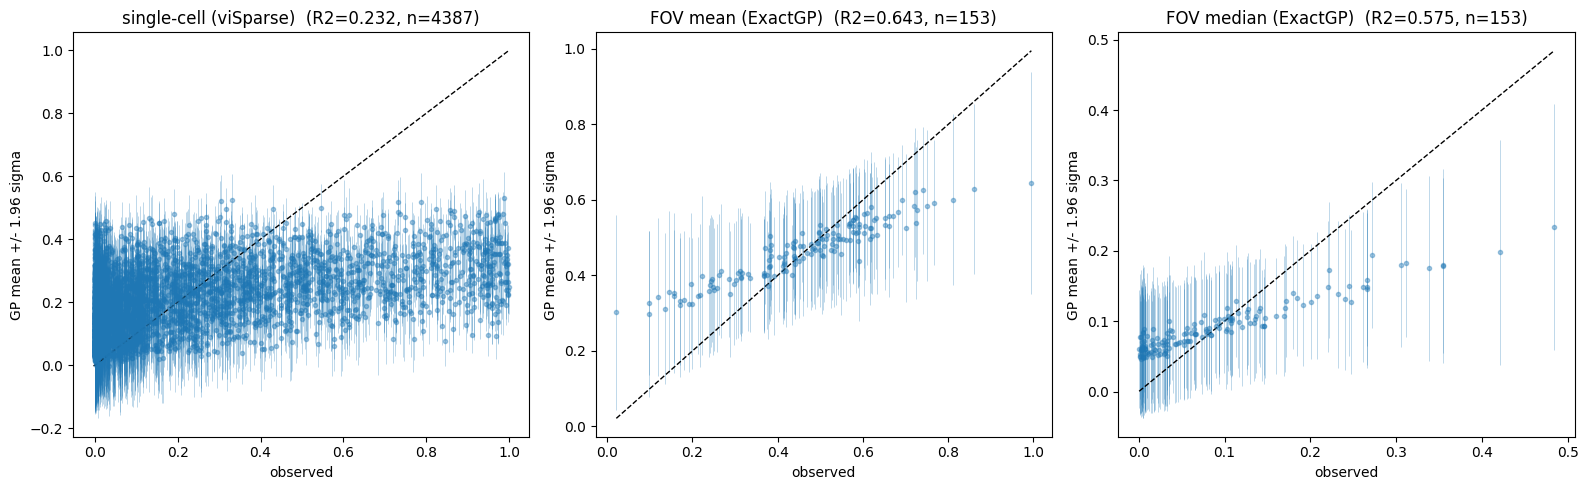

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, diag, name in zip(
    axes,
    [train_cell, train_fov, train_fov_med],
    ["single-cell (viSparse)", "FOV mean (ExactGP)", "FOV median (ExactGP)"],
):
    ax.errorbar(
        diag["y"],
        diag["mean"],
        yerr=1.96 * diag["std"],
        fmt="o",
        alpha=0.4,
        ms=3,
        lw=0.5,
    )
    lo = min(diag["y"].min(), diag["mean"].min())
    hi = max(diag["y"].max(), diag["mean"].max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    r2 = 1 - np.sum((diag["y"] - diag["mean"]) ** 2) / np.sum(
        (diag["y"] - diag["y"].mean()) ** 2
    )
    ax.set_title(f"{name}  (R2={r2:.3f}, n={len(diag['y'])})")
    ax.set_xlabel("observed")
    ax.set_ylabel("GP mean +/- 1.96 sigma")
plt.tight_layout()
plt.show()

## Holdout phase: honest generalisation

Drop the last phase, refit all three, predict the held-out observations.


Holdout phase 8
  cells: train n=3894, test n=493
  fovs : train n=136, test n=17
  Fitting vi_sparse on 3894 observations (5-D)...
  ARD lengthscales (small = highly relevant):
    stim_exposure                 lengthscale= 0.922
    ramp                          lengthscale= 0.882
    baseline_cnr                  lengthscale= 3.429
    optortk_expression            lengthscale= 0.993
    mean_dist_k_nearest           lengthscale= 3.360
    k_scale=0.217   noise=0.833
  Predicting 1880 points (94 grid x 20 cov samples)...


sample: 100%|██████████| 1200/1200 [00:11<00:00, 102.97it/s, 7 steps of size 2.77e-01. acc. prob=0.94] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.96      2.51      1.14      0.04      4.49    573.65      1.00
k_length[1]      1.70      1.87      1.18      0.11      3.43    401.28      1.00
k_length[2]      1.67      2.25      0.89      0.04      3.62    536.36      1.00
k_length[3]      1.10      1.03      0.85      0.06      2.29    397.57      1.00
k_length[4]      2.44      3.17      1.58      0.03      4.66    370.38      1.00
    k_scale      0.39      0.21      0.34      0.10      0.70    279.33      1.00
      noise      0.73      0.19      0.75      0.41      1.03    228.90      1.00

Computing robust acquisition over 1880 scenarios (94 grid points x 20 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.253912
  Robust acq stats: min=0.022671, max=0.155757


sample: 100%|██████████| 1200/1200 [00:08<00:00, 140.95it/s, 7 steps of size 4.47e-01. acc. prob=0.85]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.26      2.04      0.57      0.02      2.96    664.80      1.00
k_length[1]      1.09      1.42      0.69      0.06      2.15    411.45      1.00
k_length[2]      0.76      0.93      0.51      0.03      1.55    455.51      1.00
k_length[3]      1.61      1.75      1.13      0.07      3.24    451.54      1.00
k_length[4]      2.51      2.59      1.76      0.04      5.28    410.52      1.00
    k_scale      0.37      0.20      0.33      0.08      0.69    347.61      1.00
      noise      0.72      0.18      0.73      0.47      1.04    275.98      1.00

Computing robust acquisition over 1880 scenarios (94 grid points x 20 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.278337
  Robust acq stats: min=0.044764, max=0.214847

=== Holdout metrics (phase N predicted from phases 0..N-1) ===
              single-cell (viSparse)  FOV mean (ExactGP)  FOV median (ExactGP

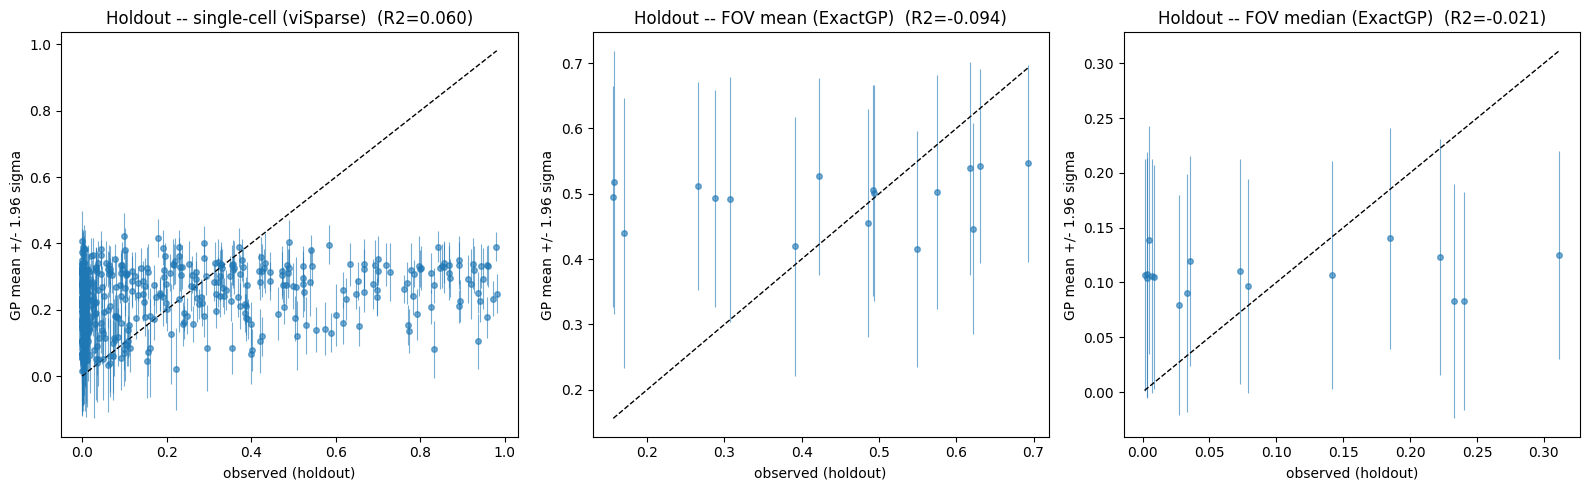

In [21]:
HOLDOUT_PHASE = max(phases)

df_cells_tr = df_cells[df_cells["phase_id"] != HOLDOUT_PHASE]
df_cells_te = df_cells[df_cells["phase_id"] == HOLDOUT_PHASE]
df_fovs_tr = df_fovs[df_fovs["phase_id"] != HOLDOUT_PHASE]
df_fovs_te = df_fovs[df_fovs["phase_id"] == HOLDOUT_PHASE]
print(f"Holdout phase {HOLDOUT_PHASE}")
print(f"  cells: train n={len(df_cells_tr)}, test n={len(df_cells_te)}")
print(f"  fovs : train n={len(df_fovs_tr)}, test n={len(df_fovs_te)}")

agent_cell.df_results = df_cells_tr.copy()
agent_cell._last_plot_context = None
_ = agent_cell._determine_next_parameters(df_cells_tr, verbose=False)

agent_fov.df_results = df_fovs_tr.copy()
agent_fov._last_plot_context = None
_ = agent_fov._determine_next_parameters(df_fovs_tr, verbose=False)

agent_fov_med.df_results = df_fovs_tr.copy()
agent_fov_med._last_plot_context = None
_ = agent_fov_med._determine_next_parameters(df_fovs_tr, verbose=False)

hold_cell = _metrics(agent_cell, df_cells_te, is_exact_mcmc=False)
hold_fov = _metrics(agent_fov, df_fovs_te, is_exact_mcmc=True)
hold_fov_med = _metrics(agent_fov_med, df_fovs_te, is_exact_mcmc=True)

summary_h = pd.DataFrame(
    {
        "single-cell (viSparse)": [
            hold_cell[k] for k in ("r2", "rmse", "nlpd", "coverage", "z_std")
        ],
        "FOV mean (ExactGP)": [
            hold_fov[k] for k in ("r2", "rmse", "nlpd", "coverage", "z_std")
        ],
        "FOV median (ExactGP)": [
            hold_fov_med[k] for k in ("r2", "rmse", "nlpd", "coverage", "z_std")
        ],
    },
    index=["R2", "RMSE", "NLPD", "95% coverage", "z-score std"],
)
print("\n=== Holdout metrics (phase N predicted from phases 0..N-1) ===")
print(summary_h.round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, diag, name in zip(
    axes,
    [hold_cell, hold_fov, hold_fov_med],
    ["single-cell (viSparse)", "FOV mean (ExactGP)", "FOV median (ExactGP)"],
):
    ax.errorbar(
        diag["y"],
        diag["mean"],
        yerr=1.96 * diag["std"],
        fmt="o",
        alpha=0.6,
        ms=4,
        lw=0.8,
    )
    lo = min(diag["y"].min(), diag["mean"].min())
    hi = max(diag["y"].max(), diag["mean"].max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    r2 = 1 - np.sum((diag["y"] - diag["mean"]) ** 2) / np.sum(
        (diag["y"] - diag["y"].mean()) ** 2
    )
    ax.set_title(f"Holdout -- {name}  (R2={r2:.3f})")
    ax.set_xlabel("observed (holdout)")
    ax.set_ylabel("GP mean +/- 1.96 sigma")
plt.tight_layout()
plt.show()

## GP-predicted landscapes side-by-side

Refits all three on the full dataset, then renders a `(stim_exposure, ramp)`
landscape by marginalising over joint samples of each agent's own
covariate distribution.


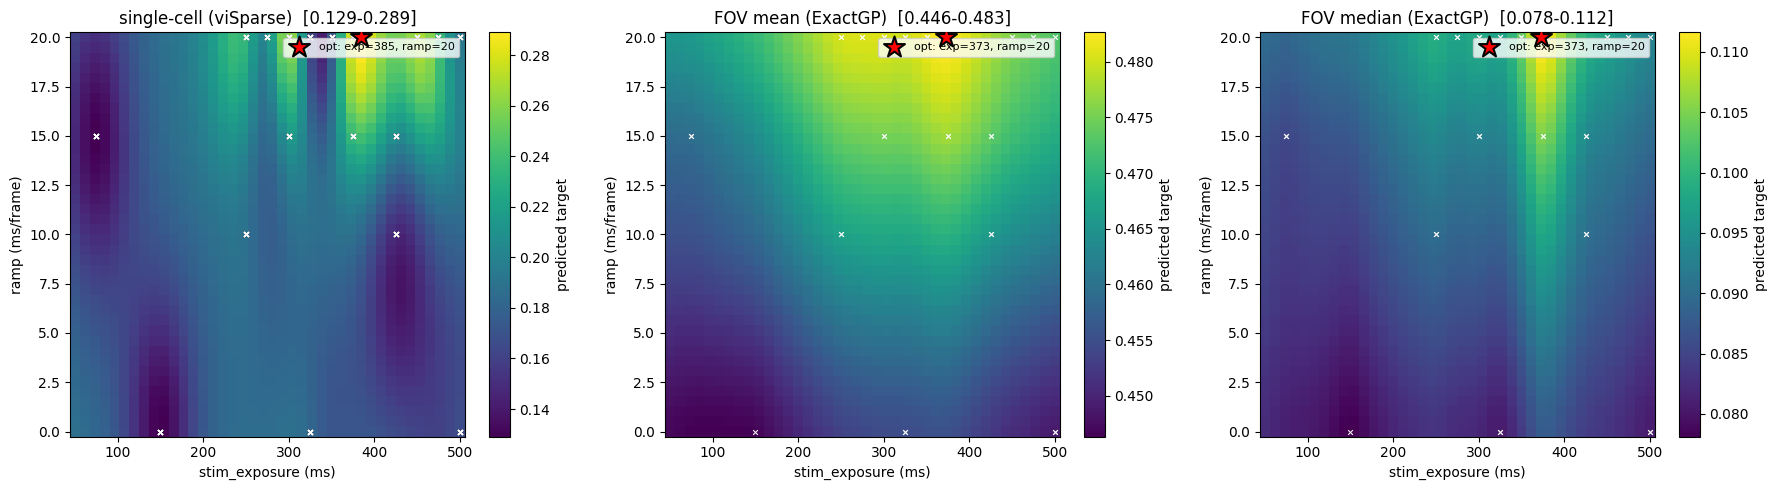

In [22]:
# Restore full-data fits cached in cell 8 (cell 15 clobbered them with holdout refits)
def _restore(agent, snap):
    agent.model = snap["model"]
    agent._x_scaler = snap["_x_scaler"]
    agent._y_scaler = snap["_y_scaler"]
    agent._rng_key_predict = snap["_rng_key_predict"]
    agent.df_results = snap["df_results"]
    agent._last_plot_context = snap["_last_plot_context"]


_restore(agent_cell, _full_fit["cell"])
_restore(agent_fov, _full_fit["fov"])
_restore(agent_fov_med, _full_fit["fov_med"])

grid_n = 40
x0_vals = np.linspace(50.0, 500.0, grid_n)
x1_vals = np.linspace(0.0, 20.0, grid_n)
X0, X1 = np.meshgrid(x0_vals, x1_vals, indexing="ij")
ctrl_grid = np.column_stack([X0.ravel(), X1.ravel()])
rng = np.random.default_rng(0)
n_mc = 25  # was 50


def _landscape(agent, df_src, cov_names, is_exact_mcmc):
    cov_vals = df_src[cov_names].to_numpy(dtype=float)
    cov_samples = cov_vals[rng.integers(0, cov_vals.shape[0], size=n_mc)]
    x_full = np.hstack(
        [
            np.repeat(ctrl_grid, n_mc, axis=0),
            np.tile(cov_samples, (ctrl_grid.shape[0], 1)),
        ]
    )
    # Mean-only landscape: skip variance, fewer posterior samples
    mean, _ = _predict_gpax(agent, x_full, is_exact_mcmc, n_samples=16, need_var=False)
    return mean.reshape(ctrl_grid.shape[0], n_mc).mean(axis=1).reshape(grid_n, grid_n)


Z_cell = _landscape(agent_cell, df_cells, [c.name for c in bo_covariates_cell], False)
Z_fov = _landscape(agent_fov, df_fovs, [c.name for c in bo_covariates_fov], True)
Z_fov_med = _landscape(
    agent_fov_med, df_fovs, [c.name for c in bo_covariates_fov], True
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, Z, df_src, name in zip(
    axes,
    [Z_cell, Z_fov, Z_fov_med],
    [df_cells, df_fovs, df_fovs],
    ["single-cell (viSparse)", "FOV mean (ExactGP)", "FOV median (ExactGP)"],
):
    im = ax.pcolormesh(
        X0,
        X1,
        Z,
        cmap="viridis",
        shading="auto",
        vmin=float(Z.min()),
        vmax=float(Z.max()),
    )
    fig.colorbar(im, ax=ax, label="predicted target")
    ax.scatter(
        df_src["stim_exposure"],
        df_src["ramp"],
        c="white",
        s=12,
        alpha=0.5,
        marker="x",
        linewidths=0.5,
    )
    opt_i = int(np.argmax(Z))
    ax.scatter(
        X0.ravel()[opt_i],
        X1.ravel()[opt_i],
        c="red",
        s=250,
        marker="*",
        edgecolors="black",
        linewidths=1.5,
        zorder=10,
        label=f"opt: exp={X0.ravel()[opt_i]:.0f}, ramp={X1.ravel()[opt_i]:.0f}",
    )
    ax.legend(loc="upper right", fontsize=8)
    ax.set_xlabel("stim_exposure (ms)")
    ax.set_ylabel("ramp (ms/frame)")
    ax.set_title(f"{name}  [{Z.min():.3f}-{Z.max():.3f}]")
plt.tight_layout()
plt.show()

## Interpretation notes

- **Single-cell vs FOV holdout R2**: FOV is expected to be dramatically
  higher because per-FOV averaging kills most of the single-cell noise.
  If the FOV holdout R2 is still <0.2, the parameters really are weak
  predictors and no amount of GP cleverness will fix it.
- **Mean vs median on FOV side**: if the median has higher holdout R2
  and better-calibrated coverage, use it -- it's saying "a few strongly
  oscillating cells inflate the FOV mean in ways unrelated to the BO
  parameters." If the mean wins, the parameters *are* moving the entire
  cell population coherently.
- **ARD agreement**: if all three backends agree on which parameter
  dominates, trust that ranking. Disagreement between single-cell and
  FOV usually means the single-cell GP is overfitting a noisy covariate.
